In [1]:
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
import taichi as ti

ti.init(
    arch=ti.cpu,
    default_fp=ti.f64,
    cpu_max_num_threads=1,
    offline_cache=False,
    debug=True,
)

from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import KaplerianHeliocentric
from tiwave.waveforms import IMRPhenomXAS, IMRPhenomXHM

import lal
import bilby

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=x64


[I 02/05/26 11:24:36.626 167527] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout
/tmp/ipykernel_167527/1519729997.py:20: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Frequency-domain response

In [2]:
f_ref = 1e-4
f_min = 1e-4
f_max = 0.1
t_start = 0.0

channels = ("A", "E", "T")
delta_time = 5
num_tsamples = 2 ** np.ceil(np.log2(4 * lal.DAYJUL_SI / delta_time))
duration = num_tsamples * delta_time
print("sample num: ", num_tsamples)
print("duration: ", duration)


params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    coalescence_time=0.0,
)
params = bilby.gw.conversion.generate_mass_parameters(params)
print(params)

sample num:  131072.0
duration:  655360.0
{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 1.3, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': 0.0, 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


In [3]:
tdi_data = TDIChannelData()
tdi_data.set_fd_data_from_zero(
    channels,
    duration,
    delta_time,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)
orbit_model = KaplerianHeliocentric(2.5e9, 0.0, 0.0)
response_model = FDResponseModelMarset2018()
tdi_combination = FDMichelsonConstantEqualArm(generation="2.0", orthogonal=True)

lisa = InterferometerAntenna(
    name="lisa",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
)


In [4]:
waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_ref)
waveform_tiw.update_waveform(params)
lisa.update_detector_response(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:69: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


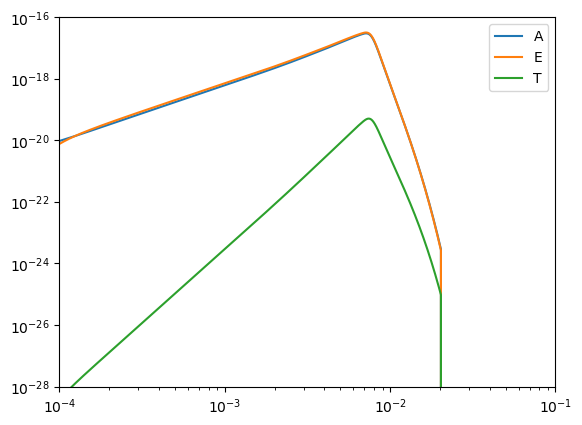

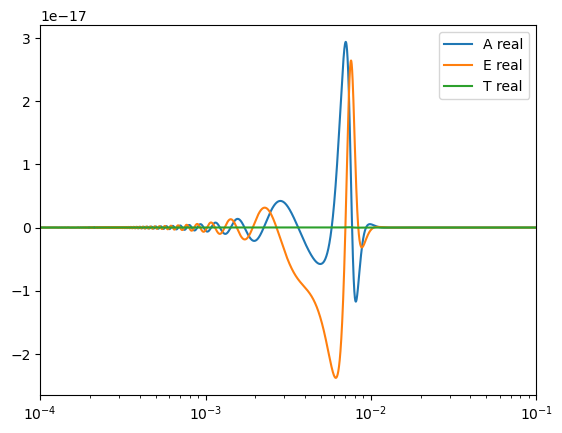

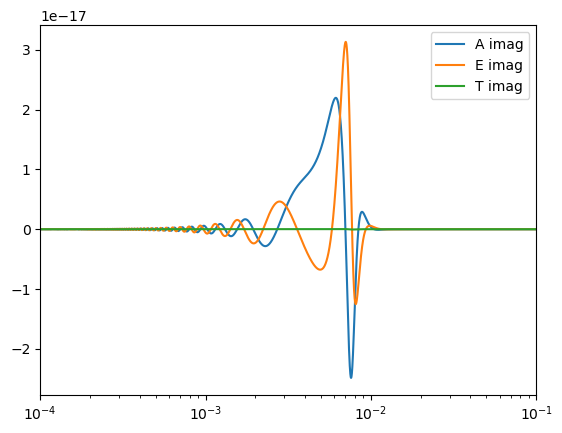

In [5]:
# abs
plt.figure()
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["A"]),
    label="A",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["E"]),
    label="E",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["T"]),
    label="T",
)
plt.ylim(1e-28, 1e-16)
plt.xlim(f_min, f_max)
plt.legend()

# real part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].real,
    label="A real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].real,
    label="E real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].real,
    label="T real",
)
plt.xlim(f_min, f_max)
plt.legend()

# imag part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].imag,
    label="A imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].imag,
    label="E imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].imag,
    label="T imag",
)
plt.xlim(f_min, f_max)
plt.legend()

## Frequency-domain response with HM

In [6]:
waveform_hm_tiw = IMRPhenomXHM(tdi_data.frequency_samples, f_ref)
waveform_hm_tiw.update_waveform(params)
lisa.update_detector_response(
    waveform_hm_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/IMRPhenomXHM.py:7038: UserWarning: Mode 32 has relatively large numerical errors with lalsim, especially for high spin and extreme mass ratio. See examples/checking_waveforms.ipynb for more details. Please make sure these errors are acceptable in your cases before using.
  warnings.warn(
/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/IMRPhenomXHM.py:7045: UserWarning: `tf` is required for mode 32, since the derivative of phase for merge-ringdown of mode 32 is obtained through numerical difference, if may not reliable for some cases.
  warnings.warn(


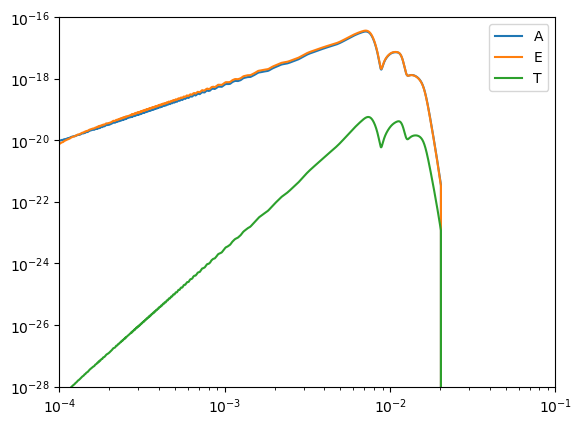

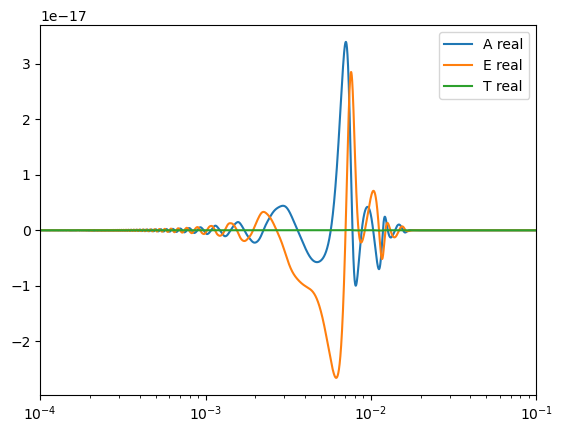

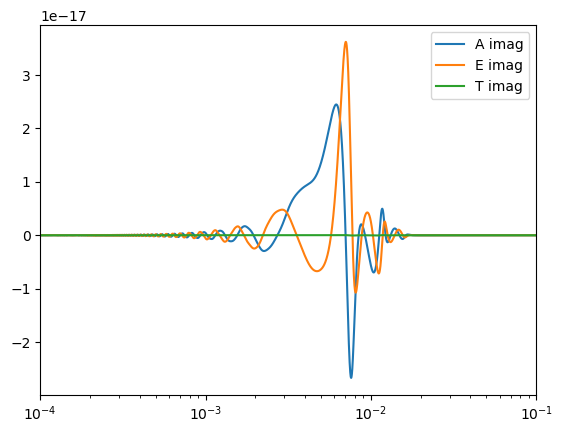

In [7]:
# abs
plt.figure()
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["A"]),
    label="A",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["E"]),
    label="E",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["T"]),
    label="T",
)
plt.ylim(1e-28, 1e-16)
plt.xlim(f_min, f_max)
plt.legend()

# real part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].real,
    label="A real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].real,
    label="E real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].real,
    label="T real",
)
plt.xlim(f_min, f_max)
plt.legend()

# imag part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].imag,
    label="A imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].imag,
    label="E imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].imag,
    label="T imag",
)
plt.xlim(f_min, f_max)
plt.legend()

In [8]:
all_modes = ['22', '21', '33', '32', '44']
tdi_resps = dict.fromkeys(all_modes)
for mode in all_modes:
    wf_mode = waveform_hm_tiw.waveform_container.get_member_field(mode)
    lisa.update_detector_response(
        wf_mode,
        params["ecliptic_longitude"],
        params["ecliptic_latitude"],
        params["polarization"],
        params["coalescence_time"],
    )
    tdi_resps[mode] = lisa.tdi_response_numpy


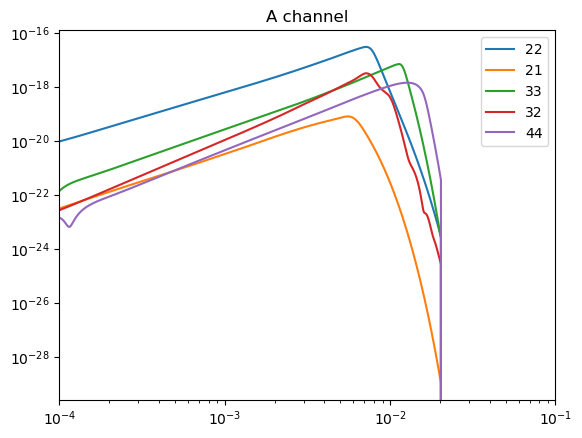

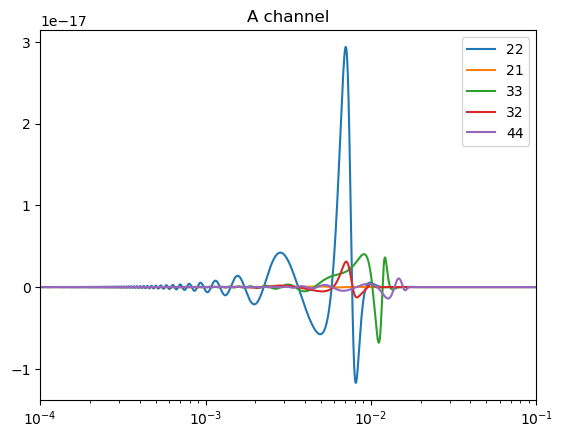

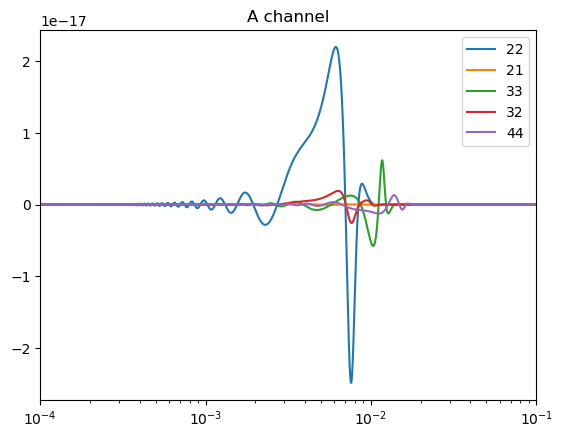

In [9]:
# A channel
# abs
plt.figure()
for mode in all_modes:
    plt.loglog(lisa.tdi_data.data_info.frequency_samples_array,
        np.abs(tdi_resps[mode]['A']),
        label=mode
    )
plt.xlim(f_min, f_max)
plt.title("A channel")
plt.legend()
# real part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['A'].real,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("A channel")
plt.legend()
# imag part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['A'].imag,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("A channel")
plt.legend()


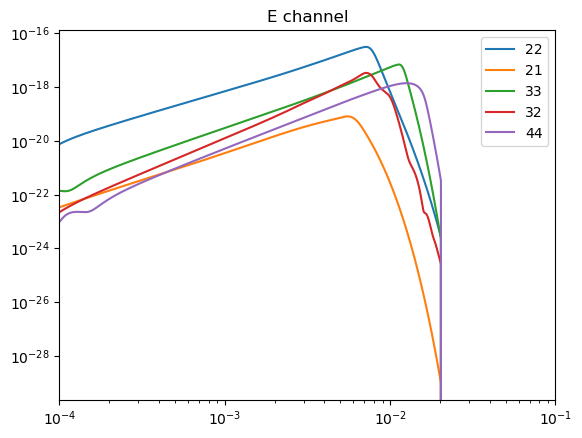

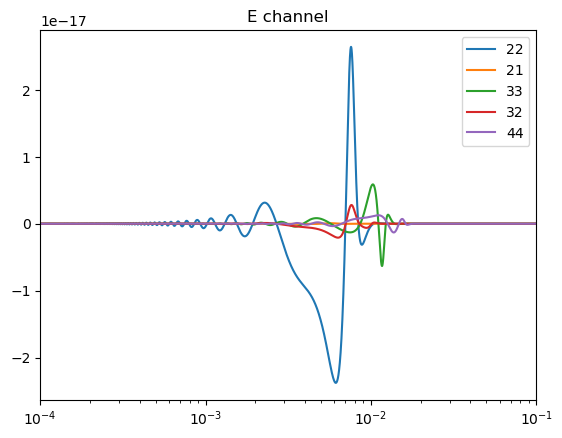

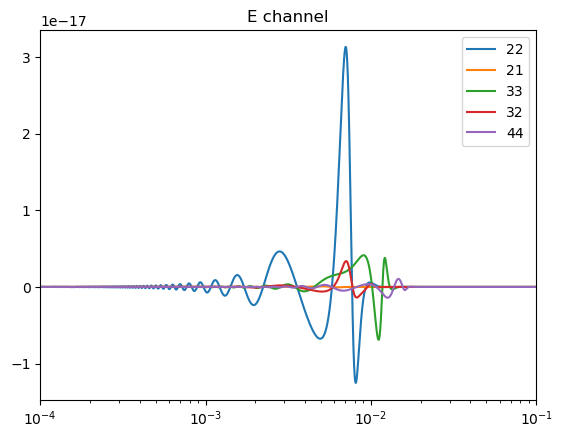

In [10]:
# E channel
plt.figure()
for mode in all_modes:
    plt.loglog(lisa.tdi_data.data_info.frequency_samples_array,
        np.abs(tdi_resps[mode]['E']),
        label=mode
    )
plt.xlim(f_min, f_max)
plt.title("E channel")
plt.legend()
# real part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['E'].real,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("E channel")
plt.legend()
# imag part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['E'].imag,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("E channel")
plt.legend()


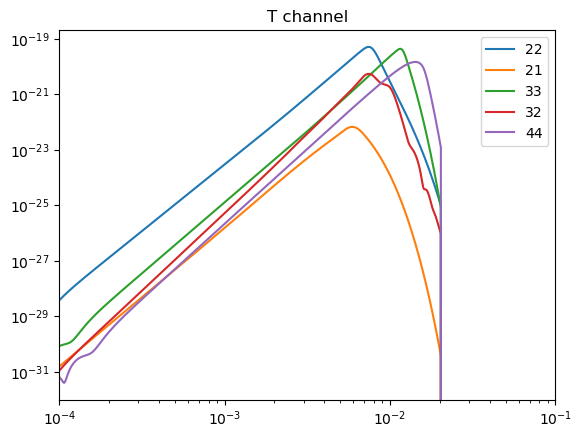

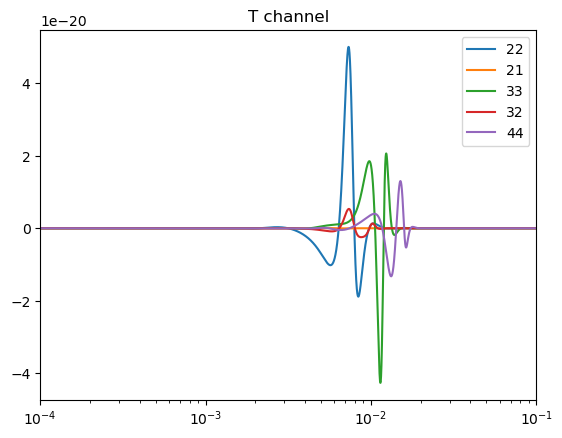

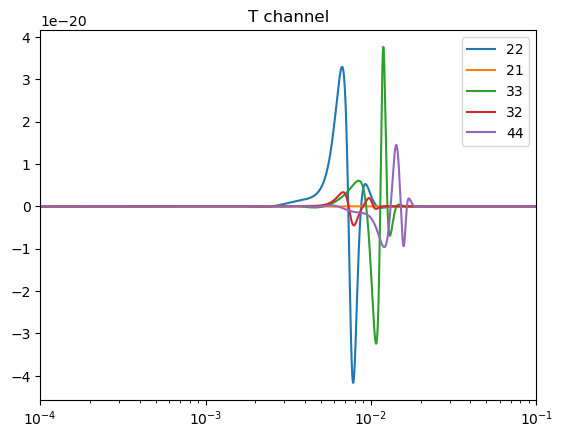

In [11]:
# T channel
plt.figure()
for mode in all_modes:
    plt.loglog(lisa.tdi_data.data_info.frequency_samples_array,
        np.abs(tdi_resps[mode]['T']),
        label=mode
    )
plt.xlim(f_min, f_max)
plt.title("T channel")
plt.legend()
# real part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['T'].real,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("T channel")
plt.legend()
# imag part
plt.figure()
for mode in all_modes:
    plt.semilogx(
        lisa.tdi_data.data_info.frequency_samples_array,
        tdi_resps[mode]['T'].imag,
        label=mode,
    )
plt.xlim(f_min, f_max)
plt.title("T channel")
plt.legend()

## Time-domain response